In [1]:
import cv2
import os
import numpy as np
import mediapipe as mp
import csv
import pickle
from collections import deque
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
# 1. Configuration
WINDOW_SIZE = 15
INPUT_CSV = 'main_coords.csv' # filename
OUTPUT_CSV = 'tmp_data.csv'

print(f"Loading raw data from {INPUT_CSV}...")
# read the csv file into pandas dataframe
df_raw = pd.read_csv(INPUT_CSV)
df_raw['class'].value_counts()

Loading raw data from main_coords.csv...


class
Arms Crossed    1028
Standing         972
Bending          939
Hand Raised      901
Sitting          880
Clapping         865
Walking          842
Jumping          736
Name: count, dtype: int64

In [3]:
LABEL_COL = 'class'
# Drop the chaotic 'Clapping' class
# df_raw = df_raw[df_raw[LABEL_COL] != 'Clapping']
# print(f"Remaining classes to process: {df_raw[LABEL_COL].unique()}")

# Get all the feature columns (everything except the label)
feature_cols = [col for col in df_raw.columns if col != LABEL_COL]

temporal_dataset = []

# 2. Process each action separately
for action_name, group_df in df_raw.groupby(LABEL_COL):
    print(f"Processing '{action_name}' (Raw rows: {len(group_df)})...")
    
    action_data = group_df[feature_cols].values
    valid_windows_created = 0
    
    # 3. Slide the 15-frame window down the rows
    for i in range(len(action_data) - WINDOW_SIZE + 1):
        # Grab the 15 sequential rows. Shape is (15, 132)
        window = action_data[i : i + WINDOW_SIZE]
        
        # --- A. STANDARD STATISTICS (396 features) ---
        temporal_mean = np.mean(window, axis=0)
        temporal_std = np.std(window, axis=0)
        temporal_range = np.ptp(window, axis=0) 
        
        # --- B. EXTRACT SPECIFIC LANDMARKS FOR THE CUSTOM MATH ---
        # Landmark index * 4 = X coordinate. +1 = Y coordinate.
        l_shoulder_x, l_shoulder_y = window[:, 44], window[:, 45]
        r_shoulder_x, r_shoulder_y = window[:, 48], window[:, 49]
        l_wrist_x, l_wrist_y       = window[:, 60], window[:, 61]
        r_wrist_x, r_wrist_y       = window[:, 64], window[:, 65]
        
        # BUG FIX: Added r_hip_x which was missing in the previous version
        l_hip_x, l_hip_y           = window[:, 92], window[:, 93]
        r_hip_x, r_hip_y           = window[:, 96], window[:, 97] 
        
        l_ankle_x, l_ankle_y       = window[:, 108], window[:, 109]
        r_ankle_x, r_ankle_y       = window[:, 112], window[:, 113]

        # --- C. CALCULATE ENGINEERED FEATURES (For all 15 frames instantly) ---
        shoulder_width = np.sqrt((l_shoulder_x - r_shoulder_x)**2 + (l_shoulder_y - r_shoulder_y)**2) + 1e-6
        
        # 1. Define centralized points for the core body axis
        mid_shoulder_x = (l_shoulder_x + r_shoulder_x) / 2
        mid_shoulder_y = (l_shoulder_y + r_shoulder_y) / 2
        mid_hip_x = (l_hip_x + r_hip_x) / 2
        mid_hip_y = (l_hip_y + r_hip_y) / 2
        
        # 2. TORSO ANGLE (Solves Bending vs Sitting)
        # np.arctan2 calculates the angle of the spine in radians relative to the camera
        torso_angle = np.arctan2(mid_hip_y - mid_shoulder_y, mid_hip_x - mid_shoulder_x)
        
        # 3. Standard Geometric Ratios
        wrist_dist = np.sqrt((l_wrist_x - r_wrist_x)**2 + (l_wrist_y - r_wrist_y)**2) / shoulder_width
        ankle_dist = np.sqrt((l_ankle_x - r_ankle_x)**2 + (l_ankle_y - r_ankle_y)**2) / shoulder_width
        l_hand_raised = (l_wrist_y - l_shoulder_y) / shoulder_width
        r_hand_raised = (r_wrist_y - r_shoulder_y) / shoulder_width
        torso_height = np.sqrt((mid_shoulder_x - mid_hip_x)**2 + (mid_shoulder_y - mid_hip_y)**2) / shoulder_width
        
        # Stack them into a custom array of shape (15 frames, 7 features)
        custom_array = np.column_stack([
            wrist_dist, ankle_dist, l_hand_raised, r_hand_raised, 
            torso_height, torso_angle, mid_hip_y
        ])
        
        # --- D. CALCULATE CUSTOM STATISTICS (14 features) ---
        custom_means = np.mean(custom_array, axis=0)
        custom_variances = np.var(custom_array, axis=0)
        
        # --- E. COMBINE EVERYTHING (396 + 7 + 7 = 410 features) ---
        combined_features = np.concatenate([
            temporal_mean, temporal_std, temporal_range, 
            custom_means, custom_variances
        ])
        
        final_row = [action_name] + combined_features.tolist()
        temporal_dataset.append(final_row)
        valid_windows_created += 1
        
    print(f" -> Generated {valid_windows_created} temporal samples for '{action_name}'")

# 4. Save the new engineered dataset
# Note: We updated the range to 410 to match our new massive feature array!
new_columns = [LABEL_COL] + [f'feat_{i}' for i in range(410)]
df_temporal = pd.DataFrame(temporal_dataset, columns=new_columns)

df_temporal.to_csv(OUTPUT_CSV, index=False)
print(f"\nSuccess! Saved {len(df_temporal)} total temporal samples to {OUTPUT_CSV}")

Processing 'Arms Crossed' (Raw rows: 1028)...
 -> Generated 1014 temporal samples for 'Arms Crossed'
Processing 'Bending' (Raw rows: 939)...
 -> Generated 925 temporal samples for 'Bending'
Processing 'Clapping' (Raw rows: 865)...
 -> Generated 851 temporal samples for 'Clapping'
Processing 'Hand Raised' (Raw rows: 901)...
 -> Generated 887 temporal samples for 'Hand Raised'
Processing 'Jumping' (Raw rows: 736)...
 -> Generated 722 temporal samples for 'Jumping'
Processing 'Sitting' (Raw rows: 880)...
 -> Generated 866 temporal samples for 'Sitting'
Processing 'Standing' (Raw rows: 972)...
 -> Generated 958 temporal samples for 'Standing'
Processing 'Walking' (Raw rows: 842)...
 -> Generated 828 temporal samples for 'Walking'

Success! Saved 7051 total temporal samples to tmp_data.csv


In [7]:
#read the temporal data
df = pd.read_csv('tmp_data.csv')
df

,class,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_400,feat_401,feat_402,feat_403,feat_404,feat_405,feat_406,feat_407,feat_408,feat_409
0,Arms Crossed,0.458005,0.149099,-0.401301,0.998119,0.472324,0.110138,-0.369435,0.997855,0.482119,...,2.147656,1.541602,0.847459,0.027304,0.001475,0.009482,0.023587,0.045213,0.000272,0.002110
1,Arms Crossed,0.463875,0.149818,-0.390693,0.998239,0.477542,0.110644,-0.359021,0.997966,0.487315,...,2.182131,1.542672,0.855896,0.026281,0.001641,0.009418,0.023182,0.041393,0.000265,0.001752
2,Arms Crossed,0.469369,0.150595,-0.381729,0.998350,0.482518,0.111831,-0.350310,0.998069,0.492304,...,2.213977,1.544019,0.862924,0.024925,0.001669,0.011677,0.023124,0.036348,0.000260,0.001542
3,Arms Crossed,0.473632,0.152388,-0.359847,0.998476,0.486121,0.114429,-0.327695,0.998197,0.495739,...,2.253439,1.545260,0.872062,0.021363,0.001298,0.013881,0.022682,0.022648,0.000253,0.000819
4,Arms Crossed,0.477224,0.155720,-0.346376,0.998593,0.489022,0.118594,-0.314121,0.998317,0.498410,...,2.284471,1.547449,0.879656,0.016469,0.001143,0.016028,0.022534,0.011894,0.000236,0.000248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7046,Walking,0.320095,0.162644,-0.459461,0.999952,0.325714,0.141775,-0.445318,0.999809,0.330793,...,1.939833,1.524484,0.543586,0.001085,0.029029,0.005877,0.007583,0.011439,0.000457,0.000277
7047,Walking,0.314295,0.166924,-0.464417,0.999950,0.319440,0.146198,-0.451850,0.999800,0.324528,...,1.933040,1.524443,0.542957,0.001202,0.041881,0.005667,0.006406,0.013375,0.000459,0.000264
7048,Walking,0.304590,0.171904,-0.472497,0.999944,0.309370,0.150182,-0.461266,0.999776,0.314478,...,1.922020,1.520989,0.544280,0.001397,0.043586,0.006325,0.006276,0.015721,0.000694,0.000323
7049,Walking,0.287110,0.174420,-0.473179,0.999935,0.291558,0.151873,-0.463112,0.999745,0.296653,...,1.906064,1.514699,0.548027,0.001462,0.049227,0.005822,0.006301,0.022833,0.000827,0.000681


In [5]:
X = df.drop('class', axis=1)
y = df['class']
y

0       Arms Crossed
1       Arms Crossed
2       Arms Crossed
3       Arms Crossed
4       Arms Crossed
            ...     
7046         Walking
7047         Walking
7048         Walking
7049         Walking
7050         Walking
Name: class, Length: 7051, dtype: str

In [10]:
#chronological splitting to avoid data leakage


# (Chronological Block Splitting):
X_train, X_test, y_train, y_test = [], [], [], []

# Group the temporal dataset by action class
for action in df['class'].unique():
    action_subset = df[df['class'] == action]
    
    # Calculate the 80% cutoff index
    split_idx = int(len(action_subset) * 0.8)
    
    # The first 80% of the timeline is Training
    train_block = action_subset.iloc[:split_idx]
    # The last 20% of the timeline is Testing
    test_block = action_subset.iloc[split_idx:]
    
    X_train.append(train_block.drop('class', axis=1))
    y_train.append(train_block['class'])
    
    X_test.append(test_block.drop('class', axis=1))
    y_test.append(test_block['class'])

# Combine the blocks back together
X_train = pd.concat(X_train)
y_train = pd.concat(y_train)
X_test = pd.concat(X_test)
y_test = pd.concat(y_test)

print(f"Training on first 80% of sequence: {len(X_train)} samples")
print(f"Testing on final 20% of sequence: {len(X_test)} samples")

Training on first 80% of sequence: 5637 samples
Testing on final 20% of sequence: 1414 samples


In [11]:
pipelines={
    'lr' : make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'rc' : make_pipeline(StandardScaler(), RidgeClassifier()),
    'rf' : make_pipeline(StandardScaler(),RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    'gb' : make_pipeline(StandardScaler(), GradientBoostingClassifier()),
}

In [ ]:
#HYPERPARAMETER TUNING FOR RANDOM FOREST-------------ONLY APPLIED TO 4TH ITERATION TRAINING SCRIPT

from sklearn.model_selection import GridSearchCV

# create the pipelines dictionary with the correct classifiers
pipelines = {
    'lr': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'rc': make_pipeline(StandardScaler(), RidgeClassifier(random_state=42)),
    'rf': make_pipeline(StandardScaler(), RandomForestClassifier()),
    'gb': make_pipeline(StandardScaler(), GradientBoostingClassifier()),
}

# 2. Corrected parameter grid with proper pipeline prefixes, quotes, and 'None'
param_grid = {
    'randomforestclassifier__n_estimators': [150, 200, 250, 300, 500],
    'randomforestclassifier__max_depth': [6, 8, 10, None],
    'randomforestclassifier__min_samples_split': [4, 8, 16],
    'randomforestclassifier__min_samples_leaf': [10, 20],
    'randomforestclassifier__max_features': ['sqrt', 0.5, 0.3],
}


grid_search = GridSearchCV(
    estimator=pipelines['rf'], 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

# Assuming X_train, y_train, X_test, y_test are already defined
grid_search.fit(X_train, y_train)

# 4. Fixed f-string print syntax
print(f"The best params: {grid_search.best_params_}")
print(f"The best score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_rf = grid_search.best_estimator_
best_cv_score = grid_search.best_score_
test_accuracy = best_rf.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")
print(f"Best cross-validation score: {best_cv_score:.4f}")

# # Train remaining models
# fit_models = {}
# for algo, pipeline in pipelines.items():
#     if algo == 'rf':
#         continue
#     else:
#         model = pipeline.fit(X_train, y_train)
#         fit_models[algo] = model


In [12]:
fit_models ={}
for algo, pipeline in pipelines.items():
    model = pipeline.fit(X_train, y_train)
    fit_models[algo] = model

In [13]:
from sklearn.metrics import accuracy_score
import pickle


for algo, model in fit_models.items():
    yhat = model.predict(X_test)
    print(algo, accuracy_score(y_test, yhat))

lr 0.8203677510608204
rc 0.8203677510608204
rf 0.7984441301272984
gb 0.8811881188118812


In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt


MODEL: LR
Accuracy  : 0.8204
Precision : 0.8362
Recall    : 0.8204
F1 Score  : 0.8246

Classification Report:

              precision    recall  f1-score   support

Arms Crossed       0.64      0.72      0.68       203
     Bending       1.00      0.88      0.93       185
    Clapping       0.45      0.51      0.48       171
 Hand Raised       0.99      1.00      0.99       178
     Jumping       1.00      0.99      1.00       145
     Sitting       0.89      0.72      0.80       174
    Standing       0.84      0.97      0.90       192
     Walking       0.92      0.78      0.85       166

    accuracy                           0.82      1414
   macro avg       0.84      0.82      0.83      1414
weighted avg       0.84      0.82      0.82      1414



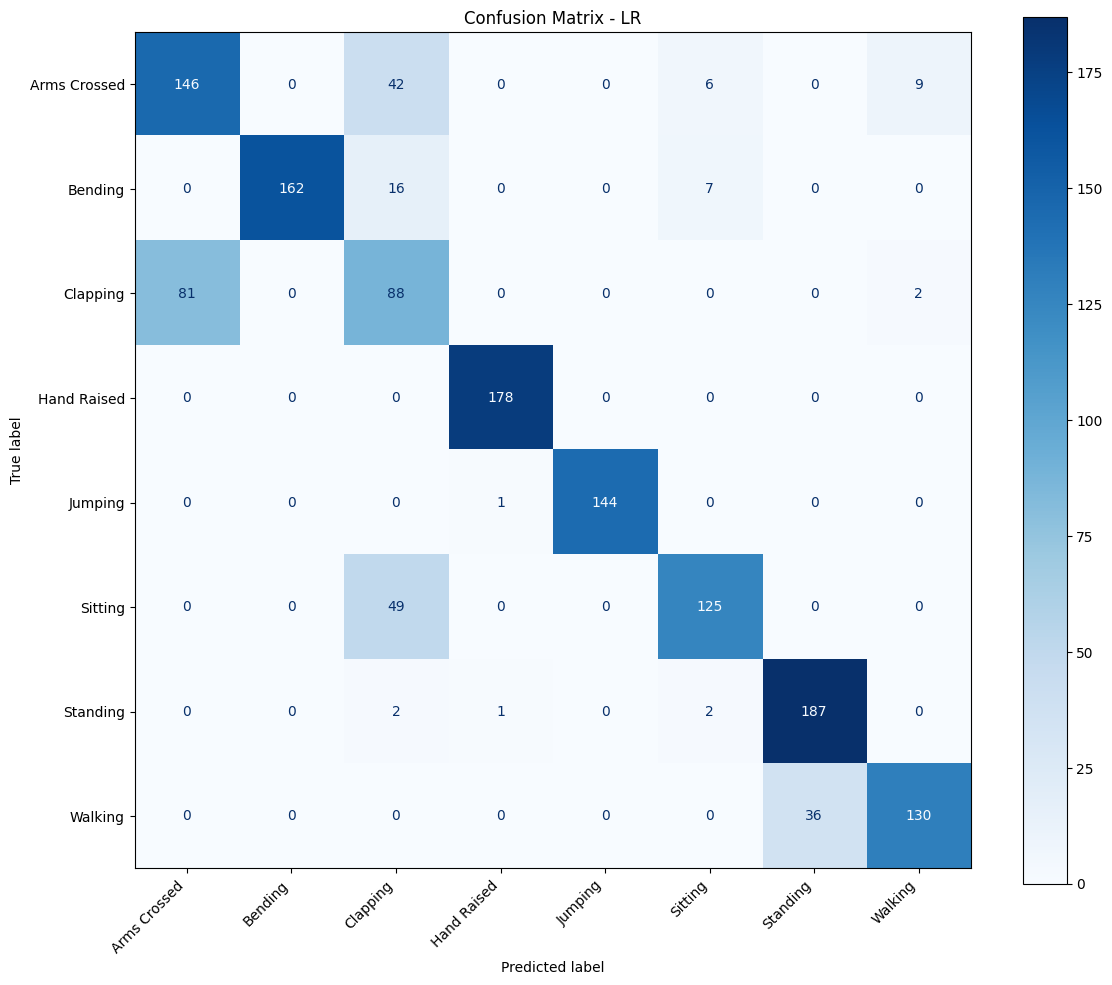


MODEL: RC
Accuracy  : 0.8204
Precision : 0.8477
Recall    : 0.8204
F1 Score  : 0.8009

Classification Report:

              precision    recall  f1-score   support

Arms Crossed       0.92      0.93      0.92       203
     Bending       0.98      0.97      0.98       185
    Clapping       0.73      0.88      0.80       171
 Hand Raised       0.97      0.93      0.95       178
     Jumping       0.99      0.98      0.99       145
     Sitting       0.90      0.72      0.80       174
    Standing       0.55      0.95      0.70       192
     Walking       0.76      0.16      0.26       166

    accuracy                           0.82      1414
   macro avg       0.85      0.81      0.80      1414
weighted avg       0.85      0.82      0.80      1414



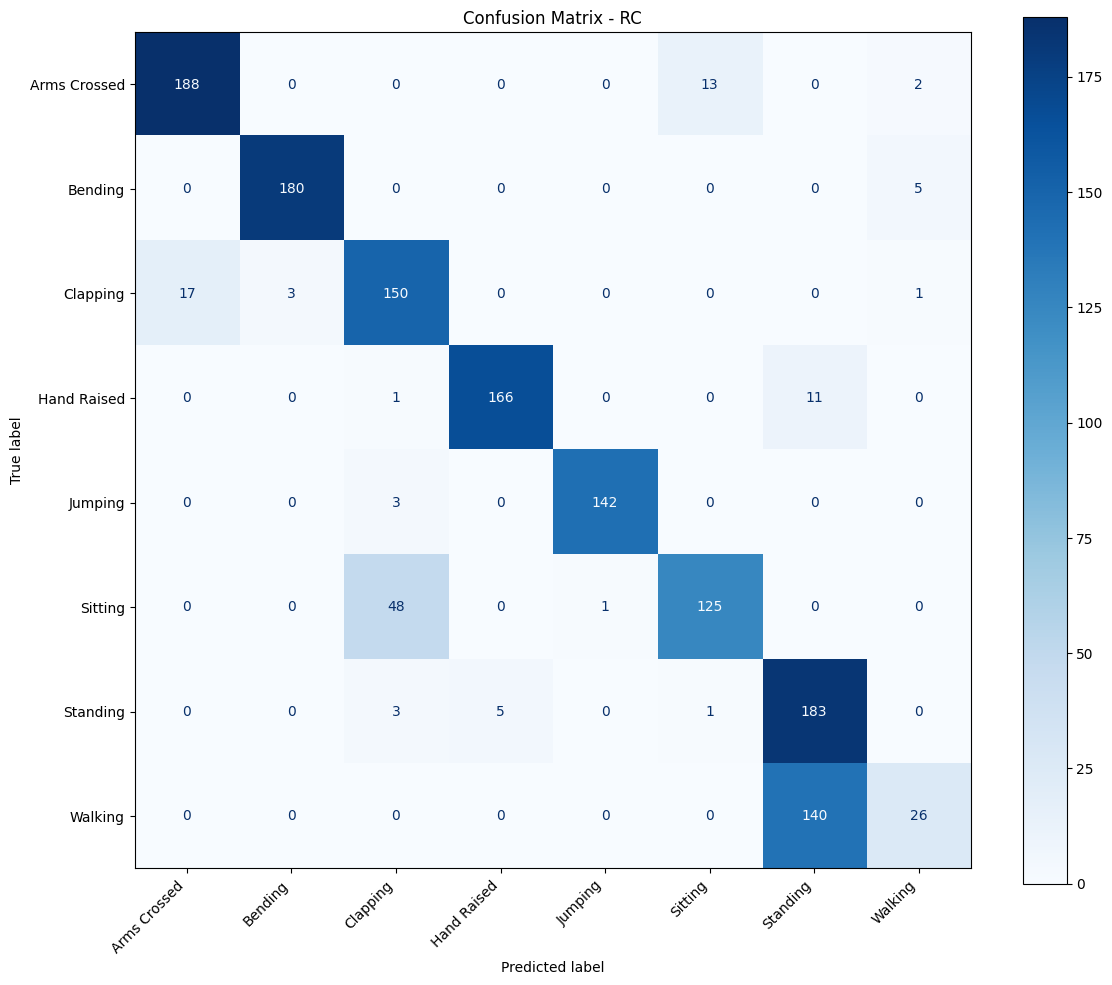


MODEL: RF
Accuracy  : 0.7984
Precision : 0.8745
Recall    : 0.7984
F1 Score  : 0.7929

Classification Report:

              precision    recall  f1-score   support

Arms Crossed       0.89      0.90      0.89       203
     Bending       1.00      0.26      0.41       185
    Clapping       0.37      0.77      0.50       171
 Hand Raised       0.93      0.99      0.96       178
     Jumping       0.99      0.99      0.99       145
     Sitting       0.90      0.51      0.65       174
    Standing       0.92      1.00      0.96       192
     Walking       0.99      1.00      1.00       166

    accuracy                           0.80      1414
   macro avg       0.87      0.80      0.80      1414
weighted avg       0.87      0.80      0.79      1414



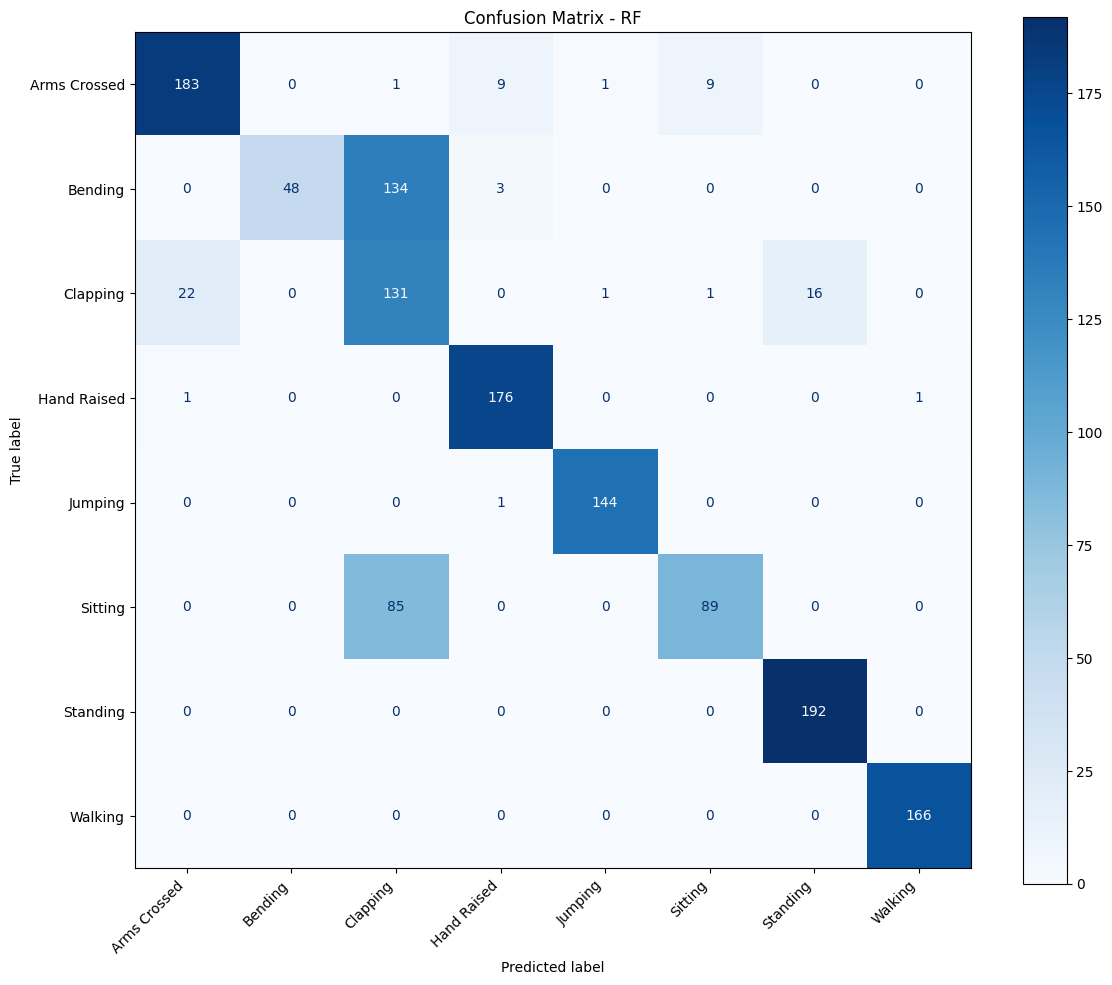


MODEL: GB
Accuracy  : 0.8812
Precision : 0.8882
Recall    : 0.8812
F1 Score  : 0.8811

Classification Report:

              precision    recall  f1-score   support

Arms Crossed       0.94      0.90      0.92       203
     Bending       0.92      0.78      0.84       185
    Clapping       0.67      0.67      0.67       171
 Hand Raised       0.98      0.98      0.98       178
     Jumping       0.90      0.91      0.91       145
     Sitting       0.93      0.80      0.86       174
    Standing       0.76      1.00      0.86       192
     Walking       1.00      1.00      1.00       166

    accuracy                           0.88      1414
   macro avg       0.89      0.88      0.88      1414
weighted avg       0.89      0.88      0.88      1414



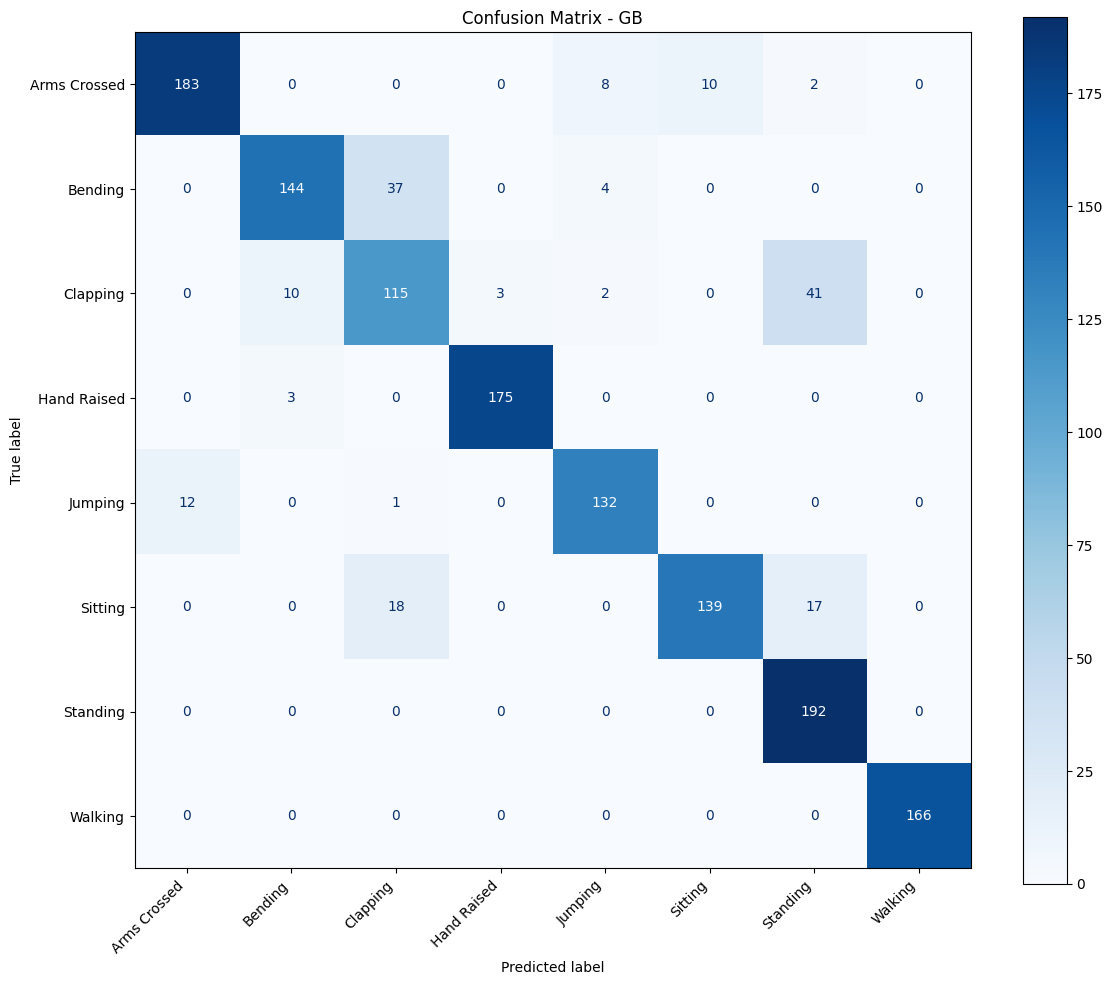

In [17]:
for algo, model in fit_models.items():
    print(f"\n{'='*50}")
    print(f"MODEL: {algo.upper()}")
    print(f"{'='*50}")

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
      # 1. Create a larger figure size BEFORE plotting (width=12, height=10 inches)
    fig, ax = plt.subplots(figsize=(12, 10))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    # 2. Pass the custom larger axis 'ax' to the plot function
    disp.plot(cmap='Blues', ax=ax)
    
    # 3. Optional: Rotate x-axis labels if they are long words
    plt.xticks(rotation=45, ha='right')
    
    plt.title(f"Confusion Matrix - {algo.upper()}")
    plt.tight_layout() # 4. Prevents labels from getting cut off at the edges
    plt.show()

In [ ]:
# 1. LOAD TRAINED RF PIPELINE
print("Loading Gradient Boost Classifier...")
with open('Human_actionV1.4.pkl', 'rb') as f:  # model
    model = pickle.load(f)

# 2. INITIALIZE MEDIAPIPE AND BUFFERS
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

WINDOW_SIZE = 15
pose_buffer = deque(maxlen=WINDOW_SIZE)
custom_buffer = deque(maxlen=WINDOW_SIZE) 

# 3. START WEBCAM
cap = cv2.VideoCapture(0)
print("Webcam active. Click the video window and press 'q' to quit.")

with mp_pose.Pose(min_detection_confidence=0.7, min_tracking_confidence=0.7, model_complexity=0) as pose_model:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
            
        frame = cv2.flip(frame, 1)
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose_model.process(image_rgb)
        
        action = "Buffering..."
        confidence = 0.0
        
        # --- EXACT CODE BLOCK STARTS HERE ---
        if results.pose_landmarks:
            pose = results.pose_landmarks.landmark
            
            # 1. Base Spatial Features
            spatial_features = [val for lm in pose for val in (lm.x, lm.y, lm.z, lm.visibility)]
            pose_buffer.append(spatial_features)
            
            # # --- HELPER ARRAYS FOR EASY MATH ---
            # l_shoulder = np.array([pose[11].x, pose[11].y])
            # r_shoulder = np.array([pose[12].x, pose[12].y])
            # l_wrist = np.array([pose[15].x, pose[15].y])
            # r_wrist = np.array([pose[16].x, pose[16].y])
            # l_hip = np.array([pose[23].x, pose[23].y])
            # r_hip = np.array([pose[24].x, pose[24].y])
            # l_ankle = np.array([pose[27].x, pose[27].y])
            # r_ankle = np.array([pose[28].x, pose[28].y])
            
            # # --- CALCULATE REFERENCE SCALE ---
            # shoulder_width = np.linalg.norm(l_shoulder - r_shoulder) + 1e-6
            
            # # --- ENGINEERED FEATURES (Appended per frame) ---
            # wrist_dist = np.linalg.norm(l_wrist - r_wrist) / shoulder_width
            # ankle_dist = np.linalg.norm(l_ankle - r_ankle) / shoulder_width
            # l_hand_raised = (pose[15].y - pose[11].y) / shoulder_width
            # r_hand_raised = (pose[16].y - pose[12].y) / shoulder_width
            # torso_height = np.linalg.norm(l_shoulder - l_hip) / shoulder_width
            
            # custom_frame_features = [
            #     wrist_dist, ankle_dist, l_hand_raised, r_hand_raised, 
            #     torso_height, pose[23].y, pose[24].y 
            # ]
            # custom_buffer.append(custom_frame_features)

            
            # --- HELPER ARRAYS FOR EASY MATH --- modified
            l_shoulder = np.array([pose[11].x, pose[11].y])
            r_shoulder = np.array([pose[12].x, pose[12].y])
            l_wrist = np.array([pose[15].x, pose[15].y])
            r_wrist = np.array([pose[16].x, pose[16].y])
            l_hip = np.array([pose[23].x, pose[23].y])
            r_hip = np.array([pose[24].x, pose[24].y])
            l_ankle = np.array([pose[27].x, pose[27].y])
            r_ankle = np.array([pose[28].x, pose[28].y])
            
            # --- CALCULATE REFERENCE SCALE ---
            shoulder_width = np.linalg.norm(l_shoulder - r_shoulder) + 1e-6
            
            # 1. Define centralized points for the core body axis
            mid_shoulder = (l_shoulder + r_shoulder) / 2.0
            mid_hip = (l_hip + r_hip) / 2.0
            
            # 2. TORSO ANGLE (Calculated on this single frame)
            # np.arctan2(y, x) -> using the numpy arrays we just created
            torso_angle = np.arctan2(mid_hip[1] - mid_shoulder[1], mid_hip[0] - mid_shoulder[0])
            
            # 3. ENGINEERED FEATURES (Appended per frame)
            wrist_dist = np.linalg.norm(l_wrist - r_wrist) / shoulder_width
            ankle_dist = np.linalg.norm(l_ankle - r_ankle) / shoulder_width
            l_hand_raised = (pose[15].y - pose[11].y) / shoulder_width
            r_hand_raised = (pose[16].y - pose[12].y) / shoulder_width
            torso_height = np.linalg.norm(mid_shoulder - mid_hip) / shoulder_width
            
            # 4. Assemble the 7 custom features EXACTLY matching training order
            custom_frame_features = [
                wrist_dist, 
                ankle_dist, 
                l_hand_raised, 
                r_hand_raised, 
                torso_height, 
                torso_angle, 
                mid_hip[1] # mid_hip_y
            ]
            custom_buffer.append(custom_frame_features)
            
            # --- INFERENCE BLOCK ---
            if len(pose_buffer) == WINDOW_SIZE:
                try:
                    buffer_array = np.array(pose_buffer)
                    temporal_mean = np.mean(buffer_array, axis=0)
                    temporal_std = np.std(buffer_array, axis=0)
                    temporal_range = np.ptp(buffer_array, axis=0)
                    
                    custom_array = np.array(custom_buffer)
                    custom_means = np.mean(custom_array, axis=0)
                    custom_variances = np.var(custom_array, axis=0)
                    
                    combined_features = np.concatenate([
                        temporal_mean, temporal_std, temporal_range, 
                        custom_means, custom_variances
                    ])
                    
                    X = pd.DataFrame([combined_features])
                    
                    # The actual prediction execution for Ridge Classifier
                    # action = model.predict(X)[0]
                    # decision_scores = model.decision_function(X)
                    # confidence = (np.max(decision_scores) / (np.sum(np.abs(decision_scores)) + 1e-6)) * 100 
                    
                    # The actual prediction execution for Random Forest
                    action = model.predict(X)[0]
                    confidence = np.max(model.predict_proba(X)) * 100                           
                    
                except Exception as e:
                    action = "Shape Error!"
                    print(f"DEBUG: {e}")
            
            mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
        # --- EXACT CODE BLOCK ENDS HERE ---

        # Draw UI
        cv2.rectangle(frame, (10, 10), (450, 100), (0, 0, 0), -1)
        cv2.putText(frame, f"ACTION: {action}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(frame, f"CONF: {confidence:.1f}%", (20, 85), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)

        cv2.imshow('Live Testing', frame)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

In [ ]:
#serialize the model to a file
with open('Human_actionV1.4.pkl', 'wb') as f:
    pickle.dump(fit_models['rf'], f)

Loading Gradient Boost Classifier...
✅ Filter applied! Changed 83 false 'Clapping' predictions to 'Standing'.

=== NEW CLASSIFICATION REPORT (WITH FILTER) ===
              precision    recall  f1-score   support

Arms Crossed       0.94      0.90      0.92       203
     Bending       0.92      0.75      0.82       185
    Clapping       0.46      0.25      0.32       171
 Hand Raised       0.98      0.99      0.98       178
     Jumping       0.89      0.91      0.90       145
     Sitting       0.94      0.80      0.86       174
    Standing       0.57      1.00      0.73       192
     Walking       1.00      1.00      1.00       166

    accuracy                           0.83      1414
   macro avg       0.84      0.82      0.82      1414
weighted avg       0.84      0.83      0.82      1414



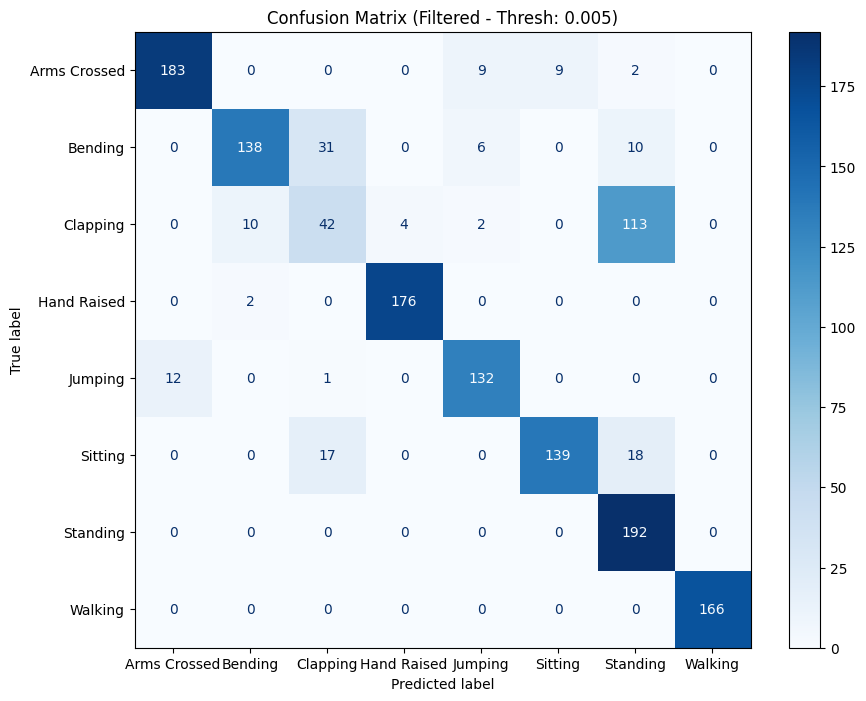

In [ ]:
# --- FILTERING FALSE POSITIVES (Clapping vs Standing) --- future implementation and improvement-----DO NOT TOUCH THIS CODE BLOCK UNLESS YOU KNOW WHAT YOU ARE DOING

print("Loading Gradient Boost Classifier...")
with open('Human_actionV1.3.pkl', 'rb') as f:  # model
    model = pickle.load(f)

# 1. Get the raw predictions from your trained model (Gradient Boosting or Random Forest)
y_pred_raw = model.predict(X_test)
y_pred_filtered = y_pred_raw.copy()

# 2. Extract the wrist variance column (feat_403) from your test data
# Handle both Pandas DataFrame or raw Numpy Array formats just in case
if isinstance(X_test, pd.DataFrame):
    wrist_variances = X_test['feat_403'].values
else:
    wrist_variances = X_test[:, 403]

# 3. Set your threshold (You can tweak this number in Jupyter to find the perfect balance)
JITTER_THRESHOLD = 0.005

# 4. Find all rows where the model guessed "Clapping" BUT the hands weren't moving enough
override_mask = (y_pred_filtered == 'Clapping') & (wrist_variances < JITTER_THRESHOLD)

# 5. Apply the override! Change those false positives to "Standing"
y_pred_filtered[override_mask] = 'Standing'

# Print the exact number of predictions the filter corrected
overridden_count = np.sum(override_mask)
print(f"✅ Filter applied! Changed {overridden_count} false 'Clapping' predictions to 'Standing'.\n")

# 6. Evaluate the new, filtered results
print("=== NEW CLASSIFICATION REPORT (WITH FILTER) ===")
print(classification_report(y_test, y_pred_filtered))

# 7. Plot the new Confusion Matrix to visually confirm the fix
cm = confusion_matrix(y_test, y_pred_filtered, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Confusion Matrix (Filtered - Thresh: {JITTER_THRESHOLD})")
plt.show()